In [1]:
import pydicom
from pathlib import Path
import os
import napari
import cv2
import json
from scipy.ndimage import rotate, shift, zoom
from functools import lru_cache
from scipy.interpolate import RegularGridInterpolator

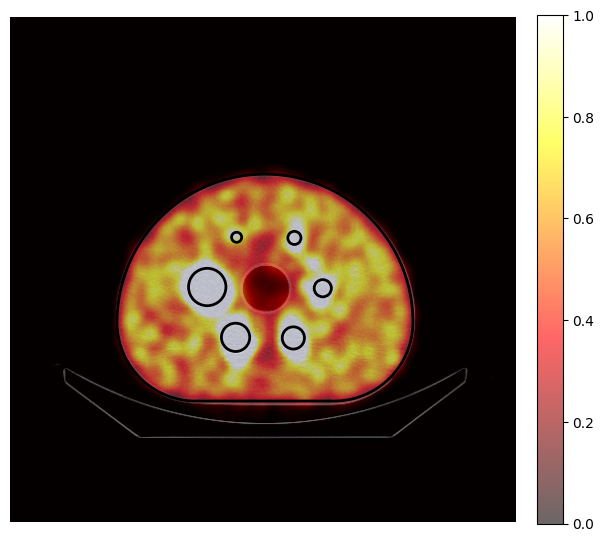

In [ ]:
import tkinter as tk
from tkinter import ttk, filedialog, messagebox
from datetime import datetime
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import pydicom
import os
from matplotlib.path import Path
import matplotlib.patches as patches

# -------------------- VARIABLES GLOBALES --------------------

archivos_ct = []      # Lista de archivos CT
archivo_spect = ""    # Archivo único SPECT

fig = None
ax = None
canvas = None

cbar = None        # Barra de colores asociada al SPECT
im_ct = None       # Objeto de imagen de Matplotlib para CT
im_spect = None    # Objeto de imagen de Matplotlib para SPECT

num_slices_ct = 1    # Numero de cortes de la imagen CT
num_slices_spect = 1 # Numero de cortes de la imagen SPECT

ct_img_sitk = None       # Imagen ct leída con SimplelTK 
spect_img_sitk = None    # Imagen spect leída con SimplelTK
spect_on_ct_sitk = None  # Imagen spect ya resampleada al grid del CT

ct_np = None    # Versión de la imagen ct en un array de Numpy
spect_np = None # Versión de la imagen spect en un array de Numpy

phantom = None # Phantom digital
mostrar_phantom = None 

# --------------------- CLASES --------------------

class Phantom2D: # Phantom digital con 6 insertos
    def __init__(self):
        self.centro = np.array([0.0, 0.0]) # Coordenadas del centro del phantom en píxeles (se actualizará al cargar el CT)
        self.centro_base = None # Para almacenar el centro original como referencia en transformaciones

        #self.radio_exterior = 115.0 # Radio exterior del phantom en mm (se convertirá a píxeles al cargar el CT)
        self.radio_insertos = 114.4 / 2 # Radio al que se encuentran los insertos desde el centro del phantom en mm (se convertirá a píxeles al cargar el CT)

        self.diametros = np.array([37, 10, 13, 17, 22, 28], dtype=float)
        self.angulos = np.array([0, 60, 120, 180, 240, 300], dtype=float)
        self.angulos_ini = self.angulos.copy() # Ángulos originales para referencia en rotaciones

    def definir_centro_desde_imagen(self, imagen_np):
        """
        Define el centro del phantom como el centro de la imagen CT.
        imagen_np debe ser un array 3D [z, y, x]
        """
        ny = imagen_np.shape[1]
        nx = imagen_np.shape[2]
        self.centro = np.array([nx/2, ny/2])

    def escalar_a_pixeles(self, spacing):
        """
        Convierte todos los parámetros geométricos de mm a píxeles.
        spacing = tamaño de pixel en mm
        """
        #self.radio_exterior /= spacing
        self.radio_insertos /= spacing
        self.diametros = np.array(self.diametros) / spacing

    def inicializar_desde_ct(self, ct_np, ct_img_sitk):
        """
        Inicializa el phantom usando una imagen CT.
        """
        self.definir_centro_desde_imagen(ct_np)

        spacing = ct_img_sitk.GetSpacing()[0]
        self.escalar_a_pixeles(spacing)
        self.centro_base = self.centro.copy() # Guardamos el centro inicial como referencia para futuras transformaciones

    def transformar(self, angulo_deg, dx, dy):
        self.centro = self.centro_base + np.array([dx, dy])
        self.angulos = self.angulos_ini + angulo_deg

    def imprime(self):
        print(self.centro)
        print(self.radio_insertos)
        print(self.angulos)

    def dibujar_contorno(self, ax, color="black"):
            
        cx = self.centro[0]
        cy = self.centro[1] + 35

        # ---- 1) Arco grande ---
        self.radio_exterior_arcogrande = 150
        theta_gran = np.linspace(0, np.pi, 100) # Ángulos para el arco grande (de 0 a 180 grados)
        x_gran = cx + self.radio_exterior_arcogrande * np.cos(theta_gran) # El eje x va hacia la derecha, así que sumamos al centro para avanzar hacia la derecha
        y_gran = cy - self.radio_exterior_arcogrande * np.sin(theta_gran) # El eje y va hacia abajo, así que restamos al centro para avanzar hacia arriba (porque el arco grande va hacia arriba del centro)

        # --- 2) Arco lateral izquierdo ---
        self.radio_lateral_izquierdo = 80
        cx_l = cx - 70
        cy_l = cy
        theta_l = np.linspace(np.pi, np.pi * 1.5, 100) # Ángulos para el arco lateral izquierdo (de 180 a 270 grados)
        x_lateral_izq = cx_l + self.radio_lateral_izquierdo * np.cos(theta_l)
        y_lateral_izq = cy_l - self.radio_lateral_izquierdo * np.sin(theta_l)

        # --- 3) Arco lateral derecho ---
        self.radio_lateral_derecho = 80
        cx_r = cx + 70
        cy_r = cy
        theta_r = np.linspace(1.5 * np.pi, 2 * np.pi, 100) # Ángulos para el arco lateral derecho (de 270 a 360 grados)
        x_lateral_dcho = cx_r + self.radio_lateral_derecho * np.cos(theta_r)
        y_lateral_dcho = cy_r - self.radio_lateral_derecho * np.sin(theta_r)

        # --- 4) Base plana ---
        x_base = np.linspace(cx - 70, cx + 70, 100)
        y_base = np.full_like(x_base, cy + 80) # La base está 80 píxeles por debajo del centro. Como el eje y va hacia abajo, sumamos al valor de cy para bajar la base.

        # --- Unir todo ---
        x_total = np.concatenate([x_gran, x_lateral_izq, x_base, x_lateral_dcho]) # Invertimos el arco grande para que el contorno se dibuje en sentido horario
        y_total = np.concatenate([y_gran, y_lateral_izq, y_base, y_lateral_dcho]) # Invertimos el arco grande para que el contorno se dibuje en sentido horario
       
        vertices = np.column_stack((x_total, y_total))

        # Cerrar el contorno correctamente
        vertices = np.vstack([vertices, vertices[0]])
        codes = [Path.MOVETO] + [Path.LINETO]*(len(vertices)-2) + [Path.CLOSEPOLY]

        path = Path(vertices, codes)
        patch = patches.PathPatch(path, fill=False, linewidth=2, color=color)

        ax.add_patch(patch)
    
    '''
    def dibujar_esferas_background(self, ax, color="black"):
        diametro = 37
    --> Twelve 37 mm diameter ROIs shall be drawn throughout the background at a distance of 15 mm from the edge of the phantom 
    but no closer than 15 mm to any sphere
    '''


    def dibujar(self, ax, color_contorno="black"):
    # Contorno exterior
        self.dibujar_contorno(ax, color_contorno)

        pos = []
        r = []
        for i,d in enumerate(self.diametros):
            current_angle_rad = np.deg2rad(self.angulos[i]) # Angle for positioning the insert
            r1   = d / 2 # Radius of the insert
            # Calculate the position of the insert's center relative to the phantom's center at a distance of self.radio_insertos
            insert_center_x = self.centro[0] + self.radio_insertos * np.cos(current_angle_rad)
            insert_center_y = self.centro[1] + self.radio_insertos * np.sin(current_angle_rad)

            pos.append([insert_center_x, insert_center_y])
            r.append(r1)

        # Insertos
        for i, c in enumerate(pos):
            ax.add_patch(
                plt.Circle(
                    np.array(c, dtype=float),
                    r[i],
                    fill=False,
                    linewidth=2,
                    color=color_contorno
                )
            )
    def coordenadas_insertos(self):
        """
        Devuelve un array Nx2 con las coordenadas (x, y) de los insertos según el phantom actual.
        """
        coords = []
        for i, d in enumerate(self.diametros):
            ang_rad = np.deg2rad(self.angulos[i])
            cx = self.centro[0] + self.radio_insertos * np.cos(ang_rad)
            cy = self.centro[1] + self.radio_insertos * np.sin(ang_rad)
            coords.append([cx, cy])
        return np.array(coords)

    def slice_max_actividad(self, spect_array):
        """
        Devuelve el índice del slice con mayor actividad dentro del phantom.
        """
        actividad_max = 0.0
        slice_max = 0

        coords = self.coordenadas_insertos()  # Coordenadas calculadas solo una vez
        radios = self.diametros / 2 # Radios calculados solo una vez

        for z in range(spect_array.shape[0]): # Recorre cada slice del SPECT
            y, x = np.indices(spect_array[z].shape) # Crea dos arrays con las coordenadas x e y de cada píxel del slice actual
            actividad_total = 0.0 # Acumula la actividad total de los insertos en este slice
            for i, r in enumerate(radios): # Recorre cada inserto definido en el phantom, usando los radios pre-calculados
                cx, cy = coords[i] # Coordenadas del centro del inserto i-ésimo, pre-calculadas
                mask = (x - cx)**2 + (y - cy)**2 <= r**2 # Máscara booleana que es True para los píxeles dentro del círculo del inserto
                actividad_total += np.sum(spect_array[z][mask])
            if actividad_total > actividad_max: # Si la actividad total de este slice es mayor que la máxima encontrada hasta ahora, actualizamos el máximo y guardamos el índice del slice
                actividad_max = actividad_total # Nueva actividad máxima encontrada
                slice_max = z # Índice del slice con mayor actividad total en los insertos
        return slice_max

    def actividad_por_insertos_en_slice(self, spect_array):
        """
        Calcula la actividad de cada inserto en el slice que tiene mayor actividad total dentro del phantom.
        """
        if spect_array is None:
            messagebox.showwarning("Atención", "No hay datos SPECT cargados")
            return
        
        slice_max = self.slice_max_actividad(spect_array) # Índice del slice con mayor actividad total en los insertos
        y, x = np.indices(spect_array[slice_max].shape) # Crea dos arrays con las coordenadas x e y de cada píxel del slice con mayor actividad

        coords = self.coordenadas_insertos()
        radios = self.diametros / 2

        actividad_list = [] # Lista para almacenar la actividad de cada inserto en este slice
        for i, r in enumerate(radios): # Recorre cada inserto definido en el phantom, usando los radios pre-calculados
            cx, cy = coords[i] # Coordenadas del centro del inserto i-ésimo, pre-calculadas
            mask = (x - cx)**2 + (y - cy)**2 <= r**2 # Máscara booleana que es True para los píxeles dentro del círculo del inserto
            actividad_list.append(np.sum(spect_array[slice_max][mask])) # Suma de la actividad de los píxeles dentro del inserto i-ésimo en el slice con mayor actividad total

        # Para imprimir en pantalla:

        # Crear lista de tuplas (diametro, actividad, indice)
        datos_insertos = [(self.diametros[i], actividad_list[i], i) for i in range(len(self.diametros))]
        # Ordenar por diámetro
        datos_insertos.sort(key=lambda x: x[0])

        # Mostrar en el widget de texto
        resumen = f"Slice con mayor actividad: {slice_max}\n\n"
        for diam, act, idx in datos_insertos:
            volumen = (4/3)*np.pi*(diam/2)**3
            resumen += f"Inserto {idx+1}: Diámetro {diam:.2f} mm → {(act/volumen):.2f} act/vol\n"

        text_resultados.config(state="normal")  # Permitir escritura
        text_resultados.delete("1.0", tk.END)   # Limpiar contenido previo
        text_resultados.insert(tk.END, resumen)
        text_resultados.config(state="disabled") # Evitar edición por el usuario



# -------------------- FUNCIONES --------------------
# global --> los cambios que se hagan dentro de la función afectarán a estas variables fuera de la función

def seleccionar_ct():
    """Seleccionar carpeta con cortes CT"""
    global archivos_ct, ct_img_sitk, ct_np, num_slices_ct, phantom

    carpeta = filedialog.askdirectory(title="Seleccionar carpeta con cortes CT (.dcm)")
    if not carpeta:
        return

    archivos_ct = carpeta
    entry_ct.delete(0, tk.END)
    entry_ct.insert(0, carpeta)

    reader = sitk.ImageSeriesReader() # Crea un lector de imagenes DICOM de SimplelTK
    series_ids = reader.GetGDCMSeriesIDs(carpeta) # Obtiene los IDs de todas las series DICOM
    file_names = reader.GetGDCMSeriesFileNames(carpeta, series_ids[0]) # obtiene los nombres
    reader.SetFileNames(file_names) 
    ct_img_sitk = reader.Execute()

    # Rango físico en Z
    origin = ct_img_sitk.GetOrigin()[2]
    spacing = ct_img_sitk.GetSpacing()[2]
    size = ct_img_sitk.GetSize()[2]
    z_end = origin + spacing * (size - 1)

    archivos_ct = file_names # Sobrescribe la variable archivos_ct con la lista de archivos individuales de la serie, en lugar de la ruta de la carpeta.

    ct_np = sitk.GetArrayFromImage(ct_img_sitk)
    num_slices_ct = ct_np.shape[0]

    ct_slider.config(to=num_slices_ct - 1)
    slice_idx_ct.set(num_slices_ct // 2)

    # Inicializar figura
    if fig is None:
        inicializar_figura()

    phantom = Phantom2D()
    phantom.inicializar_desde_ct(ct_np, ct_img_sitk)

    actualizar_overlay()

def seleccionar_fichero_spect():
    """Seleccionar archivo SPECT y convertir a numpy"""
    global archivo_spect, spect_img_sitk, spect_np, num_slices_spect 

    ruta = filedialog.askopenfilename(
        title="Seleccionar fichero SPECT",
        filetypes=[("Archivos DICOM", "*.dcm")]
    )
    if not ruta:
        return

    archivo_spect = ruta # Se guarda la ruta del archivo en la variable global
    entry_spect.delete(0, tk.END) # Borra cualquier texto que hubiera antes en el campo de texto de la interfaz
    entry_spect.insert(0, ruta)   # Inserta la ruta del archivo

    # ---------------- FECHA DICOM ----------------
    try:
        ds = pydicom.dcmread(ruta, stop_before_pixels=True)

        # Tag (0008,0022) = AcquisitionDate
        fecha_adq = ds.get("AcquisitionDate", "")

        if fecha_adq:
            fecha_formateada = datetime.strptime(fecha_adq, "%Y%m%d").strftime("%d/%m/%Y")
            entry_fecha.delete(0, tk.END)
            entry_fecha.insert(0, fecha_formateada)

    except Exception as e:
        print("No se pudo leer la fecha DICOM:", e)

    # Leer SPECT como array (SimpleITK)
    spect_img_sitk = sitk.ReadImage(ruta)

    # Rango físico en Z
    origin = spect_img_sitk.GetOrigin()[2]
    spacing = spect_img_sitk.GetSpacing()[2]
    size = spect_img_sitk.GetSize()[2]
    z_end = origin + spacing * (size - 1)

    spect_np = sitk.GetArrayFromImage(spect_img_sitk).astype(np.float32)
    num_slices_spect = spect_np.shape[0] # Guarda el número de cortes de la imagen (slices)
    
    spect_slider.config(to=num_slices_spect - 1)
    
    slice_idx_spect.set(phantom.slice_max_actividad(spect_np))

    # Inicializar figura
    if fig is None:
        inicializar_figura()

    if ct_np is not None:
        resamplear_spect_a_ct()

    actualizar_overlay()

def resamplear_spect_a_ct():

    global spect_on_ct_sitk, spect_np, spect_img_sitk, ct_img_sitk, ct_slider, num_slices_ct, num_slices_spect, vmin_spect, vmax_spect

    if spect_img_sitk is None or ct_img_sitk is None:
        return

    # Obtener rangos físicos en Z
    z_ct_min = ct_img_sitk.GetOrigin()[2] # GetOrigin() devuelve (x0, y0, z0) en milímetros
    z_ct_max = z_ct_min + ct_img_sitk.GetSpacing()[2] * (ct_img_sitk.GetSize()[2] - 1)
    z_ct_center = (z_ct_min + z_ct_max) / 2

    z_spect_min = spect_img_sitk.GetOrigin()[2]
    z_spect_max = z_spect_min + spect_img_sitk.GetSpacing()[2] * (spect_img_sitk.GetSize()[2] - 1)
        # GetSpacing()[2] → separación entre cortes en mm
        # GetSize()[2] → número total de cortes en Z
    z_spect_center = (z_spect_min + z_spect_max) / 2

    # Calcular desplazamiento necesario para centrar SPECT en CT
    delta_z = z_ct_center - z_spect_center

    # Ajustar origen del SPECT
    origin = list(spect_img_sitk.GetOrigin())
    origin[2] += delta_z
    spect_img_sitk.SetOrigin(tuple(origin))

    # Configurar resampler
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(ct_img_sitk) # La imagen resultante tendrá: El mismo spacing, El mismo size, El mismo origin y La misma dirección que la imagen de referencia (CT)
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetDefaultPixelValue(0) # Si algún voxel cae fuera del campo original tras la transformación, se le asigna valor 0

    # Transformación identidad (ya que vamos a mapear al grid del CT)
    resampler.SetTransform(sitk.Transform(3, sitk.sitkIdentity))

    # Ejecutar resample
    spect_on_ct_sitk = resampler.Execute(spect_img_sitk)

    spect_np = sitk.GetArrayFromImage(spect_on_ct_sitk).astype(np.float32)
    
    # Para la visualización, calculamos percentiles solo sobre los valores no nulos del SPECT resampleado
    non_zero = spect_np[spect_np > 0]
    if non_zero.size > 0:
        vmin_spect = np.percentile(non_zero, 5)
        vmax_spect = np.percentile(non_zero, 99)
    else:
        vmin_spect = 0
        vmax_spect = 1

    # Ajustar sliders tras el resample
    num_slices_ct = ct_np.shape[0]
    num_slices_spect = spect_np.shape[0]

    ct_slider.config(to=num_slices_ct - 1)
    spect_slider.config(to=num_slices_spect - 1)

    slice_idx_ct.set(num_slices_ct // 2)
    slice_idx_spect.set(phantom.slice_max_actividad(spect_np))

    
def guardar_datos():
    """Valida y muestra los datos introducidos"""
    fecha = entry_fecha.get()
    actividad = entry_actividad.get()

    if not archivo_spect or not archivos_ct or not fecha or not actividad:
        messagebox.showwarning("Campos incompletos", "Complete todos los campos y seleccione SPECT y CT.")
        return

    try:
        datetime.strptime(fecha, "%d/%m/%Y")
    except ValueError:
        messagebox.showerror("Error de formato", "La fecha debe tener el formato dd/mm/aaaa.")
        return

    resumen = (
        f"Datos introducidos correctamente\n\n"
        f"Archivo SPECT: {archivo_spect}\n"
        f"Carpeta CT: {entry_ct.get()} ({len(archivos_ct)} cortes)\n"
        f"Fecha: {fecha}\n"
        f"Actividad: {actividad} MBq"
    )
    messagebox.showinfo("Resumen", resumen)

# -------------------- VISUALIZACIÓN --------------------

vmin_spect = None
vmax_spect = None

def inicializar_figura():
    """Crea la figura y canvas de Matplotlib"""
    global fig, ax, canvas
    fig, ax = plt.subplots(figsize=(5,5))
    canvas = FigureCanvasTkAgg(fig, master=frame_spect)
    canvas.get_tk_widget().pack(fill="both", expand=True)
    ax.axis("off")


def actualizar_overlay():
    """Actualiza la visualización superponiendo SPECT sobre CT, alineando slices según coordenadas Z físicas"""
    global im_ct, im_spect, cbar, canvas

    if spect_np is None or ct_np is None:
        return

    # Índice del slice seleccionado para el SPECT
    z_idx_ct = int(slice_idx_ct.get())
    z_idx_spect = int(slice_idx_spect.get())

    z_idx_ct = np.clip(z_idx_ct, 0, ct_np.shape[0] - 1)
    z_idx_spect = np.clip(z_idx_spect, 0, spect_np.shape[0] - 1)

    # Inicializar o actualizar imágenes en Matplotlib

    # Normalización SOLO para visualización
    slice_raw = spect_np[z_idx_spect]
    slice_display = (slice_raw - vmin_spect) / (vmax_spect - vmin_spect)
    slice_display = np.clip(slice_display, 0, 1)

    if im_ct is None or im_spect is None:
        im_ct = ax.imshow(ct_np[z_idx_ct], cmap="bone", vmin=-200, vmax=300)
        im_spect = ax.imshow(slice_display, cmap="hot", alpha=0.6, vmin=0, vmax=1)
        ax.axis("off")
        if cbar is None:
            cbar = fig.colorbar(im_spect, ax=ax, fraction=0.046, pad=0.04)

    else:
        im_ct.set_data(ct_np[z_idx_ct])
        im_spect.set_data(slice_display)
    
    # Limpiar patches anteriores (phantom)
    for patch in ax.patches[:]:
        patch.remove()

    # Dibujar phantom si está activado
    if mostrar_phantom.get() and phantom is not None:
        phantom.dibujar(ax)

    canvas.draw_idle()

def actualizar_phantom():
    global phantom
    if phantom is not None:
        # Transformación:
        dx = phantom_dx.get()
        dy = phantom_dy.get()
        ang = phantom_rot.get()
        
        phantom.transformar(ang, dx, dy)
        
        actualizar_overlay()


# -------------------- INTERFAZ --------------------

root = tk.Tk()
root.title("Interfaz de calibración")
root.geometry("1300x700")
root.resizable(False, False)

slice_idx_ct = tk.IntVar(value=0)
slice_idx_spect = tk.IntVar(value=0)

phantom_rot = tk.DoubleVar(value=0.0)  # grados
phantom_dx  = tk.DoubleVar(value=0.0)  # píxeles
phantom_dy  = tk.DoubleVar(value=0.0)  # píxeles

# Estilos
style = ttk.Style()
style.configure("TLabel", font=("Calibri", 11))
style.configure("TButton", font=("Calibri", 10))
style.configure("TEntry", font=("Calibri", 10))

# Frames
frame_controles = ttk.Frame(root)
frame_controles.grid(row=0, column=0, sticky="ns", padx=10, pady=10)

frame_spect_container = ttk.LabelFrame(root, text="SPECT/CT")
frame_spect_container.grid(row=0, column=1, sticky="nsew", padx=10, pady=10)

root.columnconfigure(0, weight=0)
root.columnconfigure(1, weight=1)
root.rowconfigure(0, weight=1)

frame_spect = ttk.Frame(frame_spect_container)
frame_spect.pack(fill="both", expand=True)
frame_spect_container.config(width=500, height=500)
frame_spect_container.grid_propagate(False)

# Entradas y botones
ttk.Label(frame_controles, text="Carpeta CT:").grid(row=0, column=0, sticky="w", pady=4)
entry_ct = ttk.Entry(frame_controles, width=35)
entry_ct.grid(row=0, column=1, pady=4)
ttk.Button(frame_controles, text="Examinar...", command=seleccionar_ct).grid(row=0, column=2, padx=5, pady=4)

ttk.Label(frame_controles, text="Fichero SPECT:").grid(row=1, column=0, sticky="w", pady=4)
entry_spect = ttk.Entry(frame_controles, width=35)
entry_spect.grid(row=1, column=1, pady=4)
ttk.Button(frame_controles, text="Examinar...", command=seleccionar_fichero_spect).grid(row=1, column=2, padx=5, pady=4)

ttk.Label(frame_controles, text="Fecha de adquisición (dd/mm/aaaa):").grid(row=2, column=0, sticky="w", pady=4)
entry_fecha = ttk.Entry(frame_controles, width=20)
entry_fecha.grid(row=2, column=1, pady=4, sticky="w")

ttk.Label(frame_controles, text="Actividad (MBq):").grid(row=3, column=0, sticky="w", pady=4)
entry_actividad = ttk.Entry(frame_controles, width=20)
entry_actividad.grid(row=3, column=1, pady=4, sticky="w")

ttk.Button(frame_controles, text="Guardar datos", command=guardar_datos).grid(row=4, column=1, pady=12, sticky="w")

# Slider CT
ttk.Label(frame_controles, text="Slice CT").grid(row=5, column=0, sticky="w")
ct_slider = ttk.Scale(frame_controles, from_=0, to=0,
                      variable=slice_idx_ct,
                      command=lambda e: actualizar_overlay())
ct_slider.grid(row=5, column=1, columnspan=2, sticky="ew")

# Slider SPECT
ttk.Label(frame_controles, text="Slice SPECT").grid(row=6, column=0, sticky="w")
spect_slider = ttk.Scale(frame_controles, from_=0, to=0,
                         variable=slice_idx_spect,
                         command=lambda e: actualizar_overlay())
spect_slider.grid(row=6, column=1, columnspan=2, sticky="ew")

# Phantom digital
#phantom = Phantom2D()
mostrar_phantom = tk.BooleanVar(value=False)
ttk.Checkbutton(frame_controles, text="Mostrar phantom digital", variable=mostrar_phantom,
    command=actualizar_overlay).grid(row=7, column=0, columnspan=2, sticky="w")

# Rotación
ttk.Label(frame_controles, text="Rotar phantom (°):").grid(row=8, column=0, sticky="w")
ttk.Scale(frame_controles, from_=0, to=360,
          variable=phantom_rot,
          command=lambda e: actualizar_phantom()).grid(row=8, column=1, columnspan=2, sticky="ew")

# Desplazamiento X
ttk.Label(frame_controles, text="Desplazamiento X (px):").grid(row=9, column=0, sticky="w")
ttk.Scale(frame_controles, from_=-200, to=200,
          variable=phantom_dx,
          command=lambda e: actualizar_phantom()).grid(row=9, column=1, columnspan=2, sticky="ew")

# Desplazamiento Y
ttk.Label(frame_controles, text="Desplazamiento Y (px):").grid(row=10, column=0, sticky="w")
ttk.Scale(frame_controles, from_=-200, to=200,
          variable=phantom_dy,
          command=lambda e: actualizar_phantom()).grid(row=10, column=1, columnspan=2, sticky="ew")

ttk.Button(frame_controles, text="Calcular actividad", command=lambda: phantom.actividad_por_insertos_en_slice(spect_np))\
    .grid(row=11, column=1, pady=8, sticky="w")

# Frame para resultados
frame_resultados = ttk.LabelFrame(frame_controles, text="Actividad por insertos")
frame_resultados.grid(row=12, column=0, columnspan=3, pady=10, sticky="ew")

text_resultados = tk.Text(frame_resultados, width=35, height=10, state="disabled")
text_resultados.pack(fill="both", expand=True, padx=5, pady=5)


# -------------------- EJECUCIÓN --------------------
root.mainloop()



NameError: name 'x_lateral_dcho' is not defined

In [11]:
file_path = r"C:\Users\gervi\OneDrive - Universidad Complutense de Madrid (UCM)\MASTER\SEGUNDO CUATRI\TFM\Imagenes prueba\Tomo4FOV_Lu177peak_IRACSC001_DS.dcm"
ds = pydicom.dcmread(file_path)
image = ds.pixel_array

print(ds)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 210
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Nuclear Medicine Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.840.113619.2.281.40117.101394071.1759825124.8835020
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.840.113619.6.281
(0002,0013) Implementation Version Name         SH: 'Xeleris 4.0117'
(0002,0016) Source Application Entity Title     AE: 'HDOCXELERIS1'
-------------------------------------------------
(0008,0000) Group Length                        UL: 562
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['DERIVED', 'PRIMARY', 'RECON TOMO', 'EMISSION']
(0008,0012) Instance Creation Date              DA: '20251007'
(0008,0013) Insta

In [41]:
folder_path = r"C:\Users\gervi\OneDrive - Universidad Complutense de Madrid (UCM)\MASTER\SEGUNDO CUATRI\TFM\Imagenes prueba\CT"

# Listar y leer cada archivo .dcm
for filename in os.listdir(folder_path):
    if filename.endswith(".dcm"):
        path = os.path.join(folder_path, filename)
        ds = pydicom.dcmread(path)

image = ds.pixel_array

print(ds)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 210
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.840.113619.2.281.40117.101394071.1759825130.78793050
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.840.113619.6.281
(0002,0013) Implementation Version Name         SH: 'Xeleris 4.0117'
(0002,0016) Source Application Entity Title     AE: 'HDOCXELERIS1'
-------------------------------------------------
(0008,0000) Group Length                        UL: 530
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['DERIVED', 'PRIMARY', 'AXIAL']
(0008,0012) Instance Creation Date              DA: '20251007'
(0008,0013) Instance Creation Time             